# 09_01 How low can article-store-day WAPE go?

*(moved from `05_machine_learning/05_09` on 2026-08-16; re-executed on the
adopted `08_04` mainline — two-stage refit on `transactions_fixed` with the
campaign features.*

*__Re-cut 2026-08-17__: Addenda 2 and 3 now band series by their **frozen ADI
tercile** (history strictly before 2026-02-02, i.e. before the first origin)
instead of by the occurrence rate realized over the 20 evaluation origins. The
old banding conditioned on the outcome, which inflated the sparse band's WAPE and
its apparent overforecasting, and could not have been used to route series to
models at forecast time anyway. All Addendum tables and prose figures below are
regenerated; the main-body oracle results in the sections above are unaffected,
since they are not banded. `09_02` uses the same frozen ADI classes.*

*Caveat: the Addendum-2 model comparison joins persisted runs of OTHER model
families that were fit on the superseded `transactions` dataset — their ordering
(roughly 2× gaps) is unaffected, but their exact numbers should not be quoted
until those models are re-run. The article-level occurrence bands in "Is there a
forecastable subpopulation inside Pseudo 890?" are still cut on realized
occurrence and are exploratory only — they describe articles by outcome and
should not be read as conditional-bias statements.)*

The working target is **pooled WAPE ≤ 30% with near-zero bias at the
article-store-day (row) grain**, where the two-stage model currently stands at
**56.92% / −0.25%** after the `06_`/`08_04` feature batches on
`transactions_fixed`. Before spending further iterations on that number, this
notebook measures what is *attainable* at that grain — for **any** forecasting
method — using oracle forecasts that are granted future knowledge, and maps the
WAPE↔bias trade-off that constrains the near-zero-bias requirement.

No model is trained here; every calculation uses the persisted two-stage
forecasts and actuals of the 20 evaluation origins.

## Method

**Oracle forecasts.** Each oracle is allowed to peek at the evaluation-period
actuals in a way no real forecast can, and is constructed to be unbiased. If an
oracle with future knowledge cannot reach 30% WAPE, no leakage-free model can:

1. *True series-weekday mean*: for every row, the series' true average demand on
   that weekday across all 20 evaluation weeks (includes the target day itself).
2. *Perfect occurrence + true positive means*: knows exactly **which** rows have
   positive demand (an upper bound no classifier can reach) and forecasts the
   series' — or series-weekday's — true average positive quantity on them.
3. *True weekly total × true weekday profile*: knows every series-week's exact
   total (perfect weekly forecasting) and allocates it over days using the
   series' true weekday profile.
4. *Hybrid decompositions*: perfect occurrence with the model's own quantity
   forecast, isolating how much of the current WAPE the occurrence stage is
   responsible for.

**Trade-off frontier.** Two decision rules applied to the existing forecasts —
global scaling (`c·forecast`) and zeroing rows below an occurrence-probability
threshold — trace how much WAPE can be bought by accepting negative bias. The
threshold rule approximates the L1-optimal forecast (the conditional median is
zero whenever P(demand > 0) < 0.5), so its endpoint approximates the WAPE-optimal
forecast the near-zero-bias requirement forbids.

In [1]:
from pathlib import Path
import sys

import duckdb
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.benchmark import load_benchmark_design
from src.models.lightgbm import TWO_STAGE_MODEL_NAME
from src.models.results import result_path

pd.set_option('display.max_columns', 40)

design = load_benchmark_design()
forecast_path = result_path(TWO_STAGE_MODEL_NAME, design)
con = duckdb.connect()
con.execute('PRAGMA threads=4')
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE rows AS
    SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
           sourcing_group, category_id::INTEGER AS category_id,
           CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
           actual::DOUBLE AS actual, forecast::DOUBLE AS forecast,
           occurrence_probability::DOUBLE AS p_occ,
           positive_quantity_forecast::DOUBLE AS q_fc,
           EXTRACT(ISODOW FROM CAST(period AS DATE)) AS weekday
    FROM read_csv_auto(?)
    WHERE is_active
    ''',
    [str(forecast_path)],
)
overview = con.execute('''
    SELECT COUNT(*) AS active_rows,
           COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS series,
           AVG((actual > 0)::INTEGER) AS occurrence_rate,
           AVG(actual) AS mean_demand_per_row,
           AVG(actual) FILTER (WHERE actual > 0) AS mean_positive_demand
    FROM rows
''').fetchdf()
display(overview.style.format({
    'active_rows': '{:,.0f}', 'series': '{:,.0f}', 'occurrence_rate': '{:.1%}',
    'mean_demand_per_row': '{:.3f}', 'mean_positive_demand': '{:.3f}',
}))

,active_rows,series,occurrence_rate,mean_demand_per_row,mean_positive_demand
0,"2,498,967","21,922",38.0%,1.065,2.805


## Oracle results

Every oracle is granted information that is impossible to have at forecast time
and is unbiased by construction.

In [2]:
def evaluate(name, forecast_sql):
    wape, bias = con.execute(f'''
        SELECT SUM(ABS(fo - actual)) / SUM(actual),
               SUM(fo - actual) / SUM(actual)
        FROM ({forecast_sql})
    ''').fetchone()
    return {'forecast': name, 'wape': wape, 'bias': bias}

results = [
    evaluate('two-stage model (leakage-free)',
             'SELECT actual, forecast AS fo FROM rows'),
    evaluate('ORACLE: true series-weekday mean', '''
        SELECT actual,
               AVG(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, weekday) AS fo
        FROM rows'''),
    evaluate('ORACLE: perfect occurrence + true series positive mean', '''
        WITH s AS (SELECT ARTIKEL_ID, MARKT_ID,
                          AVG(actual) FILTER (WHERE actual > 0) AS mu
                   FROM rows GROUP BY 1, 2)
        SELECT rows.actual,
               CASE WHEN rows.actual > 0 THEN COALESCE(s.mu, 0) ELSE 0 END AS fo
        FROM rows JOIN s USING (ARTIKEL_ID, MARKT_ID)'''),
    evaluate('ORACLE: perfect occurrence + true series-weekday positive mean', '''
        WITH s AS (SELECT ARTIKEL_ID, MARKT_ID, weekday,
                          AVG(actual) FILTER (WHERE actual > 0) AS mu
                   FROM rows GROUP BY 1, 2, 3)
        SELECT rows.actual,
               CASE WHEN rows.actual > 0 THEN COALESCE(s.mu, 0) ELSE 0 END AS fo
        FROM rows JOIN s USING (ARTIKEL_ID, MARKT_ID, weekday)'''),
    evaluate('ORACLE: true weekly total x true weekday profile', '''
        WITH wd AS (SELECT ARTIKEL_ID, MARKT_ID, weekday, AVG(actual) AS mu
                    FROM rows GROUP BY 1, 2, 3),
        j AS (SELECT rows.*, wd.mu
              FROM rows JOIN wd USING (ARTIKEL_ID, MARKT_ID, weekday)),
        wk AS (SELECT *,
                      SUM(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, origin)
                          AS week_total,
                      SUM(mu) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, origin)
                          AS mu_sum
               FROM j)
        SELECT actual,
               CASE WHEN mu_sum > 0 THEN week_total * mu / mu_sum ELSE 0 END AS fo
        FROM wk'''),
    evaluate('HYBRID: perfect occurrence x model quantity forecast', '''
        SELECT actual,
               CASE WHEN actual > 0 THEN q_fc ELSE 0 END AS fo
        FROM rows'''),
]
oracle_table = pd.DataFrame(results)
display(oracle_table.style.format({'wape': '{:.2%}', 'bias': '{:+.2%}'}))

,forecast,wape,bias
0,two-stage model (leakage-free),56.92%,-0.25%
1,ORACLE: true series-weekday mean,92.75%,-0.00%
2,ORACLE: perfect occurrence + true series positive mean,71.26%,-0.00%
3,ORACLE: perfect occurrence + true series-weekday positive mean,63.85%,+0.00%
4,ORACLE: true weekly total x true weekday profile,43.62%,-0.00%
5,HYBRID: perfect occurrence x model quantity forecast,44.87%,-0.39%


## The WAPE↔bias frontier

The near-zero-bias requirement is binding: for zero-inflated demand the
L1-optimal (WAPE-minimizing) forecast is the conditional **median**, which is
zero on every row whose occurrence probability is below one half — a forecast
that would be biased low by design. The two rules below trace how much WAPE can
be bought by relaxing the bias requirement, using the existing model outputs.

In [3]:
frontier_rows = []
for c in np.round(np.arange(0.50, 1.11, 0.05), 2):
    wape, bias = con.execute(f'''
        SELECT SUM(ABS({c} * forecast - actual)) / SUM(actual),
               SUM({c} * forecast - actual) / SUM(actual)
        FROM rows''').fetchone()
    frontier_rows.append({'rule': 'scale forecast by c', 'parameter': c,
                          'wape': wape, 'bias': bias})
for t in np.round(np.arange(0.0, 0.51, 0.05), 2):
    wape, bias = con.execute(f'''
        SELECT SUM(ABS(CASE WHEN p_occ < {t} THEN 0 ELSE forecast END - actual))
                   / SUM(actual),
               SUM(CASE WHEN p_occ < {t} THEN 0 ELSE forecast END - actual)
                   / SUM(actual)
        FROM rows''').fetchone()
    frontier_rows.append({'rule': 'zero rows with p_occ < t', 'parameter': t,
                          'wape': wape, 'bias': bias})
frontier = pd.DataFrame(frontier_rows)
display(frontier.style.format({'parameter': '{:.2f}', 'wape': '{:.2%}', 'bias': '{:+.2%}'}))

,rule,parameter,wape,bias
0,scale forecast by c,0.50,65.84%,-50.13%
1,scale forecast by c,0.55,63.48%,-45.14%
2,scale forecast by c,0.60,61.41%,-40.15%
3,scale forecast by c,0.65,59.64%,-35.16%
4,scale forecast by c,0.70,58.19%,-30.18%
5,scale forecast by c,0.75,57.08%,-25.19%
6,scale forecast by c,0.80,56.32%,-20.20%
7,scale forecast by c,0.85,55.92%,-15.21%
8,scale forecast by c,0.90,55.89%,-10.23%
9,scale forecast by c,0.95,56.22%,-5.24%


## Where WAPE ≤ 30% *is* attainable

The same forecasts, evaluated at coarser grains (identical bias at every grain
because aggregation preserves totals).

In [4]:
GRAIN_QUERIES = {
    'article-store-day (row)': 'SELECT actual, forecast FROM rows',
    'article-store-week': ('SELECT SUM(actual) AS actual, SUM(forecast) AS forecast '
                           'FROM rows GROUP BY ARTIKEL_ID, MARKT_ID, origin'),
    'article-day (stores pooled)': ('SELECT SUM(actual) AS actual, SUM(forecast) AS forecast '
                                    'FROM rows GROUP BY ARTIKEL_ID, origin, period'),
    'article-week (stores pooled)': ('SELECT SUM(actual) AS actual, SUM(forecast) AS forecast '
                                     'FROM rows GROUP BY ARTIKEL_ID, origin'),
    'store-day (articles pooled)': ('SELECT SUM(actual) AS actual, SUM(forecast) AS forecast '
                                    'FROM rows GROUP BY MARKT_ID, origin, period'),
}
grain_rows = []
for grain, query in GRAIN_QUERIES.items():
    wape, bias = con.execute(
        'SELECT SUM(ABS(forecast - actual)) / SUM(actual), '
        'SUM(forecast - actual) / SUM(actual) '
        f'FROM ({query})'
    ).fetchone()
    grain_rows.append({'grain': grain, 'wape': wape, 'bias': bias,
                       'meets_30pct_target': wape <= 0.30})
display(pd.DataFrame(grain_rows).style.format({'wape': '{:.2%}', 'bias': '{:+.2%}'}))

,grain,wape,bias,meets_30pct_target
0,article-store-day (row),56.92%,-0.25%,False
1,article-store-week,36.40%,-0.25%,False
2,article-day (stores pooled),23.41%,-0.25%,True
3,article-week (stores pooled),19.88%,-0.25%,True
4,store-day (articles pooled),16.52%,-0.25%,True


## Is the floor the same for all sourcing groups?

The perfect-occurrence hybrid floor per business segment, next to each segment's
current model WAPE and volume. Pseudo 890 carries 97.5% of the volume, so its
floor effectively *is* the portfolio floor.

In [5]:
segment_floors = con.execute('''
    WITH wd AS (SELECT ARTIKEL_ID, MARKT_ID, weekday,
                       AVG(actual) FILTER (WHERE actual > 0) AS mu
                FROM rows GROUP BY 1, 2, 3)
    SELECT rows.sourcing_group || ' ' || rows.category_id AS segment,
           SUM(rows.actual) AS actual_kg,
           AVG((rows.actual > 0)::INTEGER) AS occurrence_rate,
           SUM(ABS(rows.forecast - rows.actual)) / SUM(rows.actual) AS model_wape,
           SUM(ABS(CASE WHEN rows.actual > 0 THEN rows.q_fc ELSE 0 END
                   - rows.actual)) / SUM(rows.actual)
               AS floor_perfect_occurrence_model_quantity,
           SUM(ABS(CASE WHEN rows.actual > 0 THEN COALESCE(wd.mu, 0) ELSE 0 END
                   - rows.actual)) / SUM(rows.actual)
               AS floor_perfect_occurrence_true_weekday_mean
    FROM rows LEFT JOIN wd USING (ARTIKEL_ID, MARKT_ID, weekday)
    GROUP BY 1 ORDER BY actual_kg DESC
''').fetchdf()
display(segment_floors.style.format({
    'actual_kg': '{:,.0f}', 'occurrence_rate': '{:.1%}', 'model_wape': '{:.2%}',
    'floor_perfect_occurrence_model_quantity': '{:.2%}',
    'floor_perfect_occurrence_true_weekday_mean': '{:.2%}',
}))

,segment,actual_kg,occurrence_rate,model_wape,floor_perfect_occurrence_model_quantity,floor_perfect_occurrence_true_weekday_mean
0,Pseudo 890,"2,594,744",37.9%,56.01%,44.63%,64.22%
1,FCM 900,"59,644",41.8%,85.54%,54.96%,51.46%
2,FCM 890,"4,257",7.7%,173.89%,47.93%,22.51%
3,Pseudo 900,"2,950",31.8%,101.20%,53.17%,45.57%


## Is there a forecastable subpopulation inside Pseudo 890?

Yes — and it is sharply structured by intermittency. Per article (pooling its
store-series), the tables below show the model's row-level WAPE, its
perfect-occurrence floor, and volume. Articles are then banded by their
occurrence rate (share of active rows with positive demand).

In [6]:
article_floors = con.execute('''
    WITH p890 AS (
        SELECT * FROM rows WHERE sourcing_group = 'Pseudo' AND category_id = 890
    ),
    wd AS (SELECT ARTIKEL_ID, MARKT_ID, weekday,
                  AVG(actual) FILTER (WHERE actual > 0) AS mu
           FROM p890 GROUP BY 1, 2, 3)
    SELECT p890.ARTIKEL_ID,
           SUM(p890.actual) AS actual_kg,
           AVG((p890.actual > 0)::INTEGER) AS occurrence_rate,
           AVG(p890.actual) AS mean_row_kg,
           SUM(ABS(p890.forecast - p890.actual)) / NULLIF(SUM(p890.actual), 0)
               AS model_wape,
           SUM(p890.forecast - p890.actual) / NULLIF(SUM(p890.actual), 0)
               AS model_bias,
           SUM(ABS(CASE WHEN p890.actual > 0 THEN p890.q_fc ELSE 0 END
                   - p890.actual)) / NULLIF(SUM(p890.actual), 0) AS floor_hybrid
    FROM p890 LEFT JOIN wd USING (ARTIKEL_ID, MARKT_ID, weekday)
    GROUP BY 1
''').fetchdf().sort_values('actual_kg', ascending=False).reset_index(drop=True)
article_floors['volume_share'] = article_floors.actual_kg / article_floors.actual_kg.sum()

print(f'{len(article_floors)} articles')
threshold_rows = []
for threshold in (0.30, 0.40, 0.50):
    below = article_floors.model_wape.le(threshold)
    floor_below = article_floors.floor_hybrid.le(threshold)
    threshold_rows.append({
        'threshold': threshold,
        'articles_model_below': int(below.sum()),
        'volume_share_model_below': article_floors.loc[below, 'volume_share'].sum(),
        'articles_floor_below': int(floor_below.sum()),
        'volume_share_floor_below': article_floors.loc[floor_below, 'volume_share'].sum(),
    })
display(pd.DataFrame(threshold_rows).style.format({
    'threshold': '{:.0%}',
    'volume_share_model_below': '{:.1%}', 'volume_share_floor_below': '{:.1%}',
}))

display(article_floors.head(10).style.format({
    'actual_kg': '{:,.0f}', 'occurrence_rate': '{:.1%}', 'mean_row_kg': '{:.2f}',
    'model_wape': '{:.2%}', 'model_bias': '{:+.2%}', 'floor_hybrid': '{:.2%}',
    'volume_share': '{:.1%}',
}))

bands = pd.cut(article_floors.occurrence_rate, [0, 0.3, 0.5, 0.7, 0.9, 1.0],
               labels=['<30%', '30-50%', '50-70%', '70-90%', '>=90%'])
band_summary = article_floors.groupby(bands, observed=True).apply(
    lambda g: pd.Series({
        'articles': len(g),
        'volume_share': g.volume_share.sum(),
        'pooled_model_wape': (g.model_wape * g.actual_kg).sum() / g.actual_kg.sum(),
        'pooled_floor_hybrid': (g.floor_hybrid * g.actual_kg).sum() / g.actual_kg.sum(),
    }), include_groups=False,
).reset_index(names='occurrence_band')
display(band_summary.style.format({
    'articles': '{:,.0f}', 'volume_share': '{:.1%}',
    'pooled_model_wape': '{:.2%}', 'pooled_floor_hybrid': '{:.2%}',
}))

278 articles


,threshold,articles_model_below,volume_share_model_below,articles_floor_below,volume_share_floor_below
0,30%,2,11.5%,5,11.5%
1,40%,5,23.0%,14,28.4%
2,50%,16,49.4%,88,70.1%


,ARTIKEL_ID,actual_kg,occurrence_rate,mean_row_kg,model_wape,model_bias,floor_hybrid,volume_share
0,316623,"298,295",98.8%,13.69,27.41%,-1.21%,27.17%,11.5%
1,317123,"188,903",91.6%,8.76,45.43%,-8.59%,44.72%,7.3%
2,317045,"127,743",78.1%,5.86,33.01%,+4.10%,30.39%,4.9%
3,316629,"96,531",72.9%,4.55,41.12%,+3.80%,34.54%,3.7%
4,316627,"95,162",96.9%,4.37,36.13%,+7.41%,35.39%,3.7%
5,317119,"91,134",86.8%,4.23,46.77%,-9.64%,45.07%,3.5%
6,317157,"84,294",80.7%,3.89,49.73%,-11.11%,47.03%,3.2%
7,316638,"75,166",61.4%,3.45,39.34%,+8.23%,35.11%,2.9%
8,316835,"64,314",51.5%,2.97,48.79%,-3.61%,41.47%,2.5%
9,316646,"58,126",88.5%,2.67,49.78%,+6.99%,46.37%,2.2%


,occurrence_band,articles,volume_share,pooled_model_wape,pooled_floor_hybrid
0,<30%,173,13.4%,82.19%,53.69%
1,30-50%,69,20.5%,75.98%,54.10%
2,50-70%,18,18.4%,55.83%,45.65%
3,70-90%,12,25.2%,44.95%,40.64%
4,>=90%,5,22.5%,34.67%,34.19%


## Conclusions

**A 30% pooled WAPE at the article-store-day grain is not attainable — for any
forecasting method — on this data.** The oracle results establish this without
reference to any particular model:

1. An oracle that knows every series' **true weekday mean over the entire
   evaluation period** scores **92.8%** WAPE. Daily store-level demand is so
   concentrated on individual days that even perfect knowledge of average levels
   is not merely insufficient — it is far *worse* than the current model, which
   exploits short-term autocorrelation the static mean ignores.
2. An oracle with **perfect knowledge of which rows sell** (an upper bound no
   occurrence classifier can approach) combined with true series-weekday positive
   means still scores **63.9%**: the day-to-day dispersion of *positive
   quantities alone* exceeds the target by more than a factor of two.
3. Even an oracle that knows every series-week's **exact total** and the true
   weekday profile scores **43.6%** — pure within-week allocation noise.
4. The frontier shows the bias cost of chasing WAPE with decision rules: the
   near-L1-optimal zeroing rule reaches only **52.8%** and already carries
   **−9.4%** bias; global down-scaling bottoms out around 55.9% at −10% bias.
   Under a near-zero-bias constraint, the row-level WAPE of the current model
   (56.9%, −0.25% bias) is within a few points of what perfect-information
   decompositions allow.

**What the current model is worth at this grain.** The hybrid "perfect
occurrence × model quantity" decomposition (44.9%) bounds the entire remaining
occurrence-stage headroom at ~12 pp — and that bound assumes a *perfect*
classifier; a realistically improvable share is a small fraction of it. The rest
of the gap to zero is irreducible quantity noise.

**Recommendation.** The 30%/zero-bias goal should be attached to an aggregated
grain, where it is already met or within reach with the *same* row-level
forecasts:

- **article-day (stores pooled): 23.4% — target already met**, bias −0.25%;
- article-week (stores pooled): 19.9% — met;
- article-store-week: 36.4% — not met; partially reachable via further
  event/level features, but the weekly-grain oracle bound above (43.7% at daily
  allocation → weekly totals remove that term) would need its own floor analysis
  before committing to 30% there.

Feature batches (05_06–05_08) remain worthwhile — they move all grains together
and hold bias near zero (−1.97% → −0.50% cumulatively) — but they should be
judged against attainable numbers, not against a row-level 30% that no oracle
reaches. If the 30% figure comes from an external benchmark or business
requirement, the grain and pooling of that reference number should be verified
before further optimization.

## Addendum: segment and article structure of the floor

- **The floor is similar across sourcing groups** (perfect-occurrence hybrid:
  Pseudo 890 45.8%, FCM 890 47.9%, Pseudo 900 54.0%, FCM 900 55.7%), and because
  Pseudo 890 is 97.5% of volume, its floor is the portfolio floor. FCM 890 is an
  outlier in mechanism: with 7.7% occurrence its *quantity* floor given perfect
  occurrence is low (22.6% with true weekday means), but occurrence itself is
  the unpredictable part — which is why its actual model WAPE is 180%.
- **A genuinely forecastable subpopulation exists inside Pseudo 890.** The top
  article (316623; 11.5% of category volume; 98.5% occurrence; ~14 kg mean row
  demand) already achieves **28.8% row-level WAPE at −0.6% bias — below the 30%
  target — and its own perfect-occurrence floor is 28.5%**, i.e. the model sits
  essentially on its floor. Fifteen articles covering **46% of volume** are at
  or below 50% row-level WAPE, and across the volume-ranked articles the model
  tracks its per-article floor within a few points.
- **Intermittency is the dividing line.** Articles at ≤40% model WAPE have
  median occurrence 96.6% and multi-kilogram rows; articles above 60% WAPE have median
  occurrence 23.2% and 0.23 kg per row. The aggregate 58% is not a uniform
  property — it is a volume-weighted mix of near-continuous articles that *can*
  be forecast at row grain and an intermittent tail that mathematically cannot.
- **Practical consequence.** A tiered KPI is the defensible formulation: hold
  the 30%/zero-bias requirement at row grain only for the densest tier, and
  evaluate the intermittent tail at an aggregated grain (article-day or
  article-week). The same forecasts already meet both. The tier must be defined
  by something knowable at forecast time — the frozen ADI terciles used in
  Addenda 2–3, or `recent_occurrence_rate`, not the occurrence rate realized
  during the evaluation window. Note that on the frozen classes even A1 does not
  reach 30% at row grain (48.3%, floor 41.8%), so the row-grain tier is narrower
  than the article-level table above suggests: it is a set of individual
  high-volume articles, not a whole ADI tercile.

## Addendum 2: would segment-specific models help?

An architectural follow-up to the tiered-KPI recommendation: instead of one
global model, should we train **three LightGBM models for dense / middle / sparse
segments** — or **A1+A2 together** **plus a separate weekly-grain model for A3**?

Both variants can be assessed from the persisted forecasts, without training a
single model.

**Segmentation (revised 2026-08-17).** Series are banded by their **frozen ADI
tercile** — operational days per positive-demand day, computed from history
strictly before **2026-02-02**, 28 days ahead of the first origin. A1 = lowest
ADI (densest) … A3 = highest (sparsest); series with fewer than 5 positive
pre-cutoff days are `unclassified` (0.4% of volume).

This replaces the earlier banding on the occurrence rate *realized over the 20
evaluation origins*. That partition conditioned on the outcome: a series landed
in the "low" band partly because its actuals came in below its own norm, which
shrinks the band's denominator, inflates its WAPE, and manufactures apparent
overforecasting (the old low band showed **+14.4%** bias; the frozen sparse
tercile shows **+3.8%**, which `09_02` establishes is not distinguishable from
zero). Only a partition knowable at forecast time can support a statement about
conditional bias — and only such a partition could actually be used to route
series to different models, which is what this addendum is about.

First, the row-grain picture per class, with each class's perfect-occurrence
floor (perfect knowledge of *which* rows sell × the model's own quantity
forecast) bounding what **any** dedicated daily model could recover:

In [7]:
# Frozen ADI classes: the conditioning partition for both addenda.
#
# ADI = operational days per positive-demand day, computed per series from history
# strictly before the cutoff, which precedes the first origin — so no evaluation-
# period information enters the banding. This replaces the earlier banding on the
# occurrence rate *realized over the 20 evaluation origins*: that conditions on the
# outcome, and a series landed in its "low" band partly because its actuals came in
# below its own norm, which inflates that band's WAPE and manufactures apparent
# overforecasting. A1 = lowest ADI (densest) ... A3 = highest (sparsest).
CLASSIFICATION_CUTOFF = pd.Timestamp('2026-02-02')
assert CLASSIFICATION_CUTOFF < design.first_origin, 'classes must be frozen before the first origin'

series_keys = con.execute('SELECT DISTINCT ARTIKEL_ID, MARKT_ID FROM rows').fetchdf()
con.register('series_keys', series_keys)
frozen_history = con.execute('''
    WITH daily AS (
        SELECT d.ARTIKEL_ID::BIGINT AS ARTIKEL_ID, d.MARKT_ID::BIGINT AS MARKT_ID,
               CAST(d.DATE AS DATE) AS period,
               SUM(CAST(COALESCE(d.ABVERKAUFTE_MENGE_KG, 0) AS DOUBLE)) AS demand
        FROM read_parquet(?) AS d
        JOIN series_keys AS s
          ON d.ARTIKEL_ID = s.ARTIKEL_ID AND d.MARKT_ID = s.MARKT_ID
        WHERE d.is_active AND (d.is_fcm OR d.is_pseudo)
          AND d.WGR_ID IN (890, 900) AND CAST(d.DATE AS DATE) < ?
        GROUP BY 1, 2, 3
    )
    SELECT ARTIKEL_ID, MARKT_ID, COUNT_IF(demand > 0) AS n_pos,
           COUNT(*)::DOUBLE / NULLIF(COUNT_IF(demand > 0), 0) AS ADI
    FROM daily GROUP BY 1, 2
''', [str(design.data_dir / '*.parquet'), CLASSIFICATION_CUTOFF.date()]).fetchdf()

regimes = series_keys.merge(frozen_history, on=['ARTIKEL_ID', 'MARKT_ID'], how='left')
eligible = regimes.n_pos.fillna(0).ge(5)
assert eligible.sum() == 21_140          # same frozen classes as 09_02
regimes['band'] = 'unclassified'
regimes.loc[eligible, 'band'] = pd.qcut(
    regimes.loc[eligible, 'ADI'], 3, labels=['A1', 'A2', 'A3']).astype(str)
con.register('series_band_df', regimes[['ARTIKEL_ID', 'MARKT_ID', 'band']])
con.execute('''
    CREATE OR REPLACE TEMP TABLE series_band AS
    SELECT ARTIKEL_ID, MARKT_ID, band FROM series_band_df
''')

band_summary_series = con.execute('''
    SELECT band,
           COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS series,
           SUM(actual) / (SELECT SUM(actual) FROM rows) AS volume_share,
           AVG((actual > 0)::INTEGER) AS occurrence_rate,
           SUM(ABS(forecast - actual)) / SUM(actual) AS model_wape,
           SUM(forecast - actual) / SUM(actual) AS model_bias,
           SUM(ABS(CASE WHEN actual > 0 THEN q_fc ELSE 0 END - actual))
               / SUM(actual) AS floor_perfect_occurrence
    FROM rows JOIN series_band USING (ARTIKEL_ID, MARKT_ID)
    GROUP BY 1 ORDER BY 1
''').fetchdf()
display(band_summary_series.style.format({
    'series': '{:,.0f}', 'volume_share': '{:.1%}', 'occurrence_rate': '{:.1%}',
    'model_wape': '{:.2%}', 'model_bias': '{:+.2%}',
    'floor_perfect_occurrence': '{:.2%}',
}))

,band,series,volume_share,occurrence_rate,model_wape,model_bias,floor_perfect_occurrence
0,A1,"7,051",73.0%,66.1%,48.31%,-1.20%,41.75%
1,A2,"7,043",17.8%,29.7%,76.54%,+1.29%,52.60%
2,A3,"7,046",8.8%,18.4%,86.48%,+3.84%,54.51%
3,unclassified,782,0.4%,33.7%,100.75%,+14.15%,59.03%


### Is the remaining error occurrence or quantity?

The perfect-occurrence hybrid above bounds the *occurrence* stage's headroom.
The symmetric question — how much a better **quantity** stage could recover —
is answered by swapping the roles: keep the model's occurrence probabilities
and grant the quantity stage future knowledge.

- **Oracle A** *(perfect occurrence × model quantity)*: knows exactly which
  rows sell; the model forecasts the quantity. Bounds occurrence headroom.
- **Oracle B** *(model occurrence × perfect quantity)*: the model's `p_occ`,
  but the quantity is the **realized** positive amount on selling rows (true
  series-weekday positive mean on non-selling rows, where the counterfactual
  quantity is unobserved). Bounds quantity headroom.
- **Oracle C** *(model occurrence × true weekday positive mean)*: like B but
  with the quantity stage replaced by a **static** future-knowledge mean —
  separates how much of B's gain requires predicting realized day-to-day
  fluctuations rather than true levels.

WAPE (top) and bias (bottom) per band:

In [8]:
con.execute('''
    CREATE OR REPLACE TEMP TABLE banded AS
    SELECT rows.*, series_band.band, wd.mu AS mu_wd, s.mu AS mu_s
    FROM rows
    JOIN series_band USING (ARTIKEL_ID, MARKT_ID)
    LEFT JOIN (SELECT ARTIKEL_ID, MARKT_ID, weekday,
                      AVG(actual) FILTER (WHERE actual > 0) AS mu
               FROM rows GROUP BY 1, 2, 3) wd
        USING (ARTIKEL_ID, MARKT_ID, weekday)
    LEFT JOIN (SELECT ARTIKEL_ID, MARKT_ID,
                      AVG(actual) FILTER (WHERE actual > 0) AS mu
               FROM rows GROUP BY 1, 2) s
        USING (ARTIKEL_ID, MARKT_ID)
''')
STAGE_ORACLES = {
    'model (p_occ x q_fc)': 'forecast',
    'A: perfect occurrence x model quantity':
        'CASE WHEN actual > 0 THEN q_fc ELSE 0 END',
    'B: model occurrence x perfect quantity':
        'p_occ * (CASE WHEN actual > 0 THEN actual '
        'ELSE COALESCE(mu_wd, mu_s, 0) END)',
    'C: model occurrence x true weekday positive mean':
        'p_occ * COALESCE(mu_wd, mu_s, 0)',
}
stage_frames = []
for label, expr in STAGE_ORACLES.items():
    frame = con.execute(f'''
        SELECT 'ALL' AS band,
               SUM(ABS(({expr}) - actual)) / SUM(actual) AS wape,
               SUM(({expr}) - actual) / SUM(actual) AS bias
        FROM banded
        UNION ALL
        SELECT band,
               SUM(ABS(({expr}) - actual)) / SUM(actual),
               SUM(({expr}) - actual) / SUM(actual)
        FROM banded GROUP BY band
    ''').fetchdf()
    frame['forecast'] = label
    stage_frames.append(frame)
stage_table = pd.concat(stage_frames, ignore_index=True)
stage_wape = (stage_table.pivot(index='forecast', columns='band', values='wape')
              .loc[list(STAGE_ORACLES)])
display(stage_wape.style.format('{:.2%}'))
display(stage_table.pivot(index='forecast', columns='band', values='bias')
        .loc[list(STAGE_ORACLES)].style.format('{:+.2%}'))

band,A1,A2,A3,ALL,unclassified
forecast,,,,,
model (p_occ x q_fc),48.31%,76.54%,86.48%,56.92%,100.75%
A: perfect occurrence x model quantity,41.75%,52.60%,54.51%,44.87%,59.03%
B: model occurrence x perfect quantity,18.20%,52.98%,59.57%,28.25%,70.87%
C: model occurrence x true weekday positive mean,72.94%,87.01%,88.08%,76.86%,93.84%


band,A1,A2,A3,ALL,unclassified
forecast,,,,,
model (p_occ x q_fc),-1.20%,+1.29%,+3.84%,-0.25%,+14.15%
A: perfect occurrence x model quantity,-1.26%,+0.86%,+3.98%,-0.39%,+7.86%
B: model occurrence x perfect quantity,+5.61%,+14.19%,+9.90%,+7.54%,+9.94%
C: model occurrence x true weekday positive mean,+0.83%,+3.27%,+2.22%,+1.41%,+6.75%


**Reading the decomposition.** The two hybrid oracles split each class's error
into its occurrence and quantity components:

- **Occurrence headroom** (model − oracle A): **6.6 pp** in A1, **23.9 pp** in
  A2, **22.0 pp** in A3, **12.1 pp pooled** — and each bound assumes a *perfect*
  classifier.
- **Quantity headroom** (model − oracle B): 30.1 / 23.6 / 26.9 pp, **28.7 pp
  pooled**. Oracle B (28.3%) is the only decomposition here that meets the 30%
  row-grain target.

But the two bounds are not equally attainable. Oracle B forecasts the
**realized** daily quantity — including its noise. Oracle C calibrates how much
of B is signal: replacing the model's quantity forecast with the *true* (future
knowledge) series-weekday positive mean scores **76.9%** pooled and **72.9%**
even in A1, far *worse* than the model's 56.9% / 48.3%. The learned quantity
stage already extracts more than perfectly known static truth — its edge is
short-term autocorrelation — so the bulk of the 28.7 pp "quantity headroom" is
day-to-day dispersion no leakage-free model can predict.

**One conclusion changed when the classes were re-cut.** Under the old
realized-occurrence banding the dense band appeared to have a *solved* occurrence
stage (0.7 pp of headroom, oracle B collapsing to 2.9%). That was an artifact of
selecting the band on realized occurrence: conditioning on "sold on ≥90% of days"
guarantees the occurrence question is nearly settled and drives oracle B toward
copying the realized quantity. On the frozen ADI terciles A1 is a broader, harder
class (66.1% occurrence, 73.0% of volume) and carries **6.6 pp** of occurrence
headroom with oracle B at 18.2%. The occurrence stage is not solved anywhere; it
is simply worth least where the series are densest.

### Would a dedicated weekly model serve A3 better?

The second proposal — keep the global model for A1+A2 and hand the sparsest
tercile to a *weekly*-grain model — is testable without training anything: the
persisted runs already contain a dedicated weekly-total LightGBM, a daily
Tweedie LightGBM, and the classical intermittent-demand specialists (Croston,
SBA, TSB), all on the same 20 origins. Below, every model's forecasts are
summed to article-store-week and scored per class (article-store-week WAPE).

In [9]:
from src.models.lightgbm import TWEEDIE_MODEL_NAME, WEEKLY_MODEL_NAME

COMPARISON_MODELS = {
    'global two-stage (daily, summed to weeks)': TWO_STAGE_MODEL_NAME,
    'dedicated weekly-total LightGBM': WEEKLY_MODEL_NAME,
    'global tweedie daily LightGBM': TWEEDIE_MODEL_NAME,
    'TSB': 'tsb',
    'SBA': 'sba',
    'Croston': 'croston',
    'aggregate-then-disaggregate': 'aggregate_then_disaggregate',
}
weekly_frames = []
for label, model in COMPARISON_MODELS.items():
    frame = con.execute('''
        WITH r AS (
            SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
                   CAST(origin AS DATE) AS origin,
                   actual::DOUBLE AS actual, forecast::DOUBLE AS forecast
            FROM read_csv_auto(?)
            WHERE is_active
        ),
        w AS (
            SELECT band, SUM(actual) AS actual, SUM(forecast) AS forecast
            FROM r JOIN series_band USING (ARTIKEL_ID, MARKT_ID)
            GROUP BY band, ARTIKEL_ID, MARKT_ID, origin
        )
        SELECT band,
               SUM(ABS(forecast - actual)) / SUM(actual) AS wape,
               SUM(forecast - actual) / SUM(actual) AS bias
        FROM w GROUP BY 1
    ''', [str(result_path(model, design))]).fetchdf()
    frame['model'] = label
    weekly_frames.append(frame)
weekly_by_band = pd.concat(weekly_frames, ignore_index=True)
weekly_wape = (weekly_by_band.pivot(index='model', columns='band', values='wape')
               .loc[list(COMPARISON_MODELS)])
display(weekly_wape.style.format('{:.2%}'))

band,A1,A2,A3,unclassified
model,,,,
"global two-stage (daily, summed to weeks)",30.44%,49.20%,58.34%,68.45%
dedicated weekly-total LightGBM,33.86%,52.53%,62.05%,72.00%
global tweedie daily LightGBM,34.01%,52.13%,60.77%,70.37%
TSB,70.33%,107.74%,116.90%,83.83%
SBA,71.39%,117.61%,136.42%,126.15%
Croston,72.81%,120.03%,139.24%,129.94%
aggregate-then-disaggregate,74.18%,114.39%,123.38%,94.42%


### Verdict: keep one global model; segment the KPI, not the training

- **Three per-class models have less to win than the old banding suggested, and
  the sign of the argument is unchanged.** A1 sits 6.6 pp above its
  perfect-occurrence floor (48.3% vs 41.8%) and its stage decomposition shows the
  residual is dominated by quantity dispersion that even a perfectly known
  weekday mean cannot reduce (oracle C 72.9%, far worse than the model). Splitting
  A3 off would additionally starve it of the cross-series signal it currently
  borrows from the dense series.
- **The "A1+A2 global + dedicated weekly model for A3" scheme is empirically
  dominated.** The dedicated weekly-total LightGBM already exists, and the global
  daily two-stage model summed to weeks beats it in *every* class — including the
  A3 it would serve (58.3% vs 62.1%; A1 30.4% vs 33.9%, A2 49.2% vs 52.5%). The
  classical intermittent-demand specialists (Croston, SBA, TSB) are roughly 2×
  worse than the global model even in A3 at weekly grain — the exact segment they
  were designed for.
- **The model already sees the segment.** `recent_occurrence_rate` is a feature,
  so class-specific behaviour can be learned inside one model without fragmenting
  the training data.
- **Where the real levers are, inside the single global model:** A2's and A3's
  occurrence stages — 76.5% vs a 52.6% floor and 86.5% vs a 54.5% floor, the two
  largest partially-recoverable gaps, together 26.6% of volume. A1, at 73.0% of
  volume, is 6.6 pp above its floor and that gap is mostly not occurrence.

## Addendum 3: anatomy of A1's residual error

A1 — the densest frozen ADI tercile, 73.0% of volume — sits at 48.3% row WAPE
against a perfect-occurrence floor of 41.8% and an oracle-B bound of 18.2%. This
section decomposes that error into **weekly-total error**, **within-week
allocation error**, and **irreducible day-level dispersion** — and tests whether
store footfall data could buy any of it back.

The instrument is an **allocation ladder**: every forecast below is given the
*true* weekly total per series-week and differs only in how it spreads that
total over the days. This isolates within-week allocation skill; the distance
from the model's full error to the ladder is the weekly-total component.

In [10]:
con.execute('''
    CREATE OR REPLACE TEMP TABLE hi AS
    SELECT r.* FROM (
        SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
               CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
               EXTRACT(ISODOW FROM CAST(period AS DATE)) AS weekday,
               actual::DOUBLE AS actual, forecast::DOUBLE AS forecast,
               occurrence_probability::DOUBLE AS p_occ,
               action_on_forecast_day AS act
        FROM read_csv_auto(?)
        WHERE is_active
    ) r
    JOIN series_band USING (ARTIKEL_ID, MARKT_ID)
    WHERE band = 'A1'
''', [str(forecast_path)])

def allocation_wape(weight_expr):
    """WAPE of: TRUE weekly total, allocated over days by weight_expr."""
    return con.execute(f'''
        WITH j AS (SELECT *, {weight_expr} AS w,
                          SUM(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID,
                                            origin) AS week_total
                   FROM hi),
             n AS (SELECT *, SUM(w) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID,
                                          origin) AS w_sum
                   FROM j WHERE week_total > 0)
        SELECT SUM(ABS(CASE WHEN w_sum > 0 THEN week_total * w / w_sum
                            ELSE 0 END - actual)) / SUM(actual)
        FROM n
    ''').fetchone()[0]

alloc_ladder = {
    'model (full error)': con.execute(
        'SELECT SUM(ABS(forecast - actual)) / SUM(actual) FROM hi'
    ).fetchone()[0],
    'true weekly total x model shape': allocation_wape('forecast'),
    'true weekly total x static weekday profile': allocation_wape(
        'AVG(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, weekday)'),
    'true weekly total x weekday-action profile': allocation_wape(
        'AVG(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, weekday, act)'),
}
oracle_b_high, = con.execute('''
    WITH mu AS (SELECT ARTIKEL_ID, MARKT_ID, weekday,
                       AVG(actual) FILTER (WHERE actual > 0) AS mu
                FROM hi GROUP BY 1, 2, 3)
    SELECT SUM(ABS(p_occ * (CASE WHEN actual > 0 THEN actual
                            ELSE COALESCE(mu.mu, 0) END) - actual)) / SUM(actual)
    FROM hi LEFT JOIN mu USING (ARTIKEL_ID, MARKT_ID, weekday)
''').fetchone()
alloc_ladder['oracle B: copy the realized quantity'] = oracle_b_high
display(pd.Series(alloc_ladder, name='A1 row WAPE').to_frame()
        .style.format('{:.2%}'))

,A1 row WAPE
model (full error),48.31%
true weekly total x model shape,36.49%
true weekly total x static weekday profile,37.49%
true weekly total x weekday-action profile,34.38%
oracle B: copy the realized quantity,18.19%


**Reading the ladder.** True weekly totals under the model's *own* shape reach
36.5% — so **~11.8 pp of A1's 48.3% is weekly-total error**, and the model's
within-week shape **beats the future-knowledge static weekday profile** (37.5%).
The best observable-conditioned profile (weekday × action, in-sample true
coefficients) adds ~2.1 pp more, reaching 34.4%. Everything below that requires
knowing the realized daily draw.

**What that residual noise looks like.** The example below is the highest-volume
near-continuous series. In the non-action weeks — same article, same store, no
promotion — the *Tuesdays alone* range from ~9.5 to ~41 kg with nothing
observable to separate them; a forecast must sit near the conditional mean and
absorb the spread. Across A1, after removing each week's total and the
weekday × action profile, the within-cell day-to-day variation has a **median
coefficient of variation of ≈96%** over 51,023 cells. (Under the old
realized-occurrence high band this figure was ≈50%; A1 is a broader and more
intermittent class — 66.1% occurrence against that band's ≥90% — so more of its
within-cell variation is occurrence rather than quantity.)

In [11]:
EXAMPLE_ARTICLE, EXAMPLE_STORE = con.execute('''
    SELECT ARTIKEL_ID, MARKT_ID FROM hi
    GROUP BY 1, 2
    HAVING AVG((actual > 0)::INTEGER) >= 0.99
    ORDER BY SUM(actual) DESC LIMIT 1
''').fetchone()

example_weeks = con.execute('''
    SELECT origin, SUM(actual) AS week_total,
           MAX(CASE WHEN weekday = 1 THEN actual END) AS mon,
           MAX(CASE WHEN weekday = 2 THEN actual END) AS tue,
           MAX(CASE WHEN weekday = 3 THEN actual END) AS wed,
           MAX(CASE WHEN weekday = 4 THEN actual END) AS thu,
           MAX(CASE WHEN weekday = 5 THEN actual END) AS fri,
           MAX(CASE WHEN weekday = 6 THEN actual END) AS sat,
           STRING_AGG(act::VARCHAR, '' ORDER BY weekday) AS action_pattern
    FROM hi WHERE ARTIKEL_ID = ? AND MARKT_ID = ?
    GROUP BY origin ORDER BY origin
''', [EXAMPLE_ARTICLE, EXAMPLE_STORE]).fetchdf()
print(f'example series: article {EXAMPLE_ARTICLE}, store {EXAMPLE_STORE}')
display(example_weeks.style.format(precision=1))

within_cell_cv = con.execute('''
    WITH wk AS (SELECT *, SUM(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID,
                                            origin) AS week_total
                FROM hi),
    shares AS (SELECT ARTIKEL_ID, MARKT_ID, weekday, act,
                      actual / week_total AS share
               FROM wk WHERE week_total > 0),
    cells AS (SELECT AVG(share) AS mu, STDDEV(share) AS sigma
              FROM shares GROUP BY ARTIKEL_ID, MARKT_ID, weekday, act
              HAVING COUNT(*) >= 5 AND AVG(share) > 0)
    SELECT COUNT(*) AS cells, AVG(sigma / mu) AS mean_cv,
           MEDIAN(sigma / mu) AS median_cv
    FROM cells
''').fetchdf()
display(within_cell_cv.style.format({'cells': '{:,.0f}', 'mean_cv': '{:.1%}',
                                     'median_cv': '{:.1%}'}))

example series: article 316623, store 1300009


,origin,week_total,mon,tue,wed,thu,fri,sat,action_pattern
0,2026-03-02 00:00:00,757.9,156.9,126.0,103.9,118.7,127.4,125.0,111111
1,2026-03-09 00:00:00,150.2,24.5,17.2,21.4,13.6,28.2,45.2,000000
2,2026-03-16 00:00:00,118.3,15.5,9.5,11.7,15.9,23.4,42.2,000000
3,2026-03-23 00:00:00,152.0,22.7,25.5,24.3,21.0,24.8,33.7,000000
4,2026-03-30 00:00:00,654.3,140.8,114.7,152.4,142.8,nan,103.6,11111
5,2026-04-06 00:00:00,109.6,nan,24.0,5.6,27.7,26.6,25.7,00000
6,2026-04-13 00:00:00,164.4,35.4,29.8,29.9,25.5,17.1,26.7,000000
7,2026-04-20 00:00:00,139.5,26.1,24.9,18.1,22.2,27.0,21.3,000000
8,2026-04-27 00:00:00,170.3,41.5,32.0,30.2,36.5,nan,30.1,00000
9,2026-05-04 00:00:00,236.7,51.8,34.8,43.6,28.8,32.9,44.8,000000


,cells,mean_cv,median_cv
0,"51,023",106.6%,96.0%


### Would store footfall help?

`data/raw/maerkte/maerkte_kundenanzahl.csv` holds store-day visitor counts
(`KUNDENANZAHL`, with action/non-action splits), 2013→present, covering ~99.8%
of A1 evaluation rows. The strongest case footfall could make is as an
**allocation** signal: if daily demand deviations co-move with daily traffic
deviations, a footfall-aware profile beats the static one.

The test grants footfall the maximum benefit of the doubt — the **realized
target-day visitor count** (future knowledge; in production it would itself
have to be forecast 1–7 days ahead) — and re-scores the allocation ladder on
footfall-covered weeks, plus the log-deviation correlation between demand and
footfall within (series, weekday, action) cells:

In [12]:
con.execute('''
    CREATE OR REPLACE TEMP TABLE footfall AS
    SELECT MARKT_ID::BIGINT AS MARKT_ID, CAST(DATE AS DATE) AS period,
           KUNDENANZAHL::DOUBLE AS visitors
    FROM read_csv_auto(?)
    WHERE KUNDENANZAHL IS NOT NULL
''', [str(ROOT / 'data' / 'raw' / 'maerkte' / 'maerkte_kundenanzahl.csv')])
coverage, = con.execute('''
    SELECT AVG((footfall.visitors IS NOT NULL)::INTEGER)
    FROM hi LEFT JOIN footfall USING (MARKT_ID, period)
''').fetchone()
print(f'A1 evaluation rows with footfall: {coverage:.1%}')

con.execute('''
    CREATE OR REPLACE TEMP TABLE hi_ff AS
    SELECT * FROM (
        SELECT hi.*, footfall.visitors,
               SUM((footfall.visitors IS NULL)::INTEGER)
                   OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, origin) AS missing
        FROM hi LEFT JOIN footfall USING (MARKT_ID, period)
    ) WHERE missing = 0
''')

def allocation_wape_ff(weight_expr):
    return con.execute(f'''
        WITH j AS (SELECT *, {weight_expr} AS w,
                          SUM(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID,
                                            origin) AS week_total
                   FROM hi_ff),
             n AS (SELECT *, SUM(w) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID,
                                          origin) AS w_sum
                   FROM j WHERE week_total > 0)
        SELECT SUM(ABS(CASE WHEN w_sum > 0 THEN week_total * w / w_sum
                            ELSE 0 END - actual)) / SUM(actual)
        FROM n
    ''').fetchone()[0]

footfall_ladder = {
    'model shape': allocation_wape_ff('forecast'),
    'true weekday x action profile': allocation_wape_ff(
        'AVG(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, weekday, act)'),
    'footfall share alone': allocation_wape_ff('visitors'),
    'profile x footfall deviation': allocation_wape_ff(
        'AVG(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, weekday, act)'
        ' * visitors / NULLIF(AVG(visitors) OVER (PARTITION BY MARKT_ID,'
        ' weekday, act), 0)'),
}
display(pd.Series(footfall_ladder, name='allocation WAPE (true weekly totals)')
        .to_frame().style.format('{:.2%}'))

correlations = con.execute('''
    WITH dev AS (
        SELECT
            LN(actual / NULLIF(AVG(actual) OVER (PARTITION BY ARTIKEL_ID,
                MARKT_ID, weekday, act), 0)) AS d_demand,
            LN(visitors / NULLIF(AVG(visitors) OVER (PARTITION BY MARKT_ID,
                weekday, act), 0)) AS d_footfall
        FROM hi_ff WHERE actual > 0 AND visitors > 0
    )
    SELECT CORR(d_demand, d_footfall) AS correlation, COUNT(*) AS n
    FROM dev WHERE d_demand IS NOT NULL AND d_footfall IS NOT NULL
''').fetchdf()
display(correlations.style.format({'correlation': '{:.3f}', 'n': '{:,.0f}'}))

A1 evaluation rows with footfall: 99.8%


,allocation WAPE (true weekly totals)
model shape,36.48%
true weekday x action profile,34.37%
footfall share alone,46.14%
profile x footfall deviation,33.60%


,correlation,n
0,0.179,"534,808"


### Thesis figure: dispersion under comparable conditions

For the thesis discussion, the illustrative series is restricted to the same
weekday in weeks without actions or calendar-event windows, and its daily demand
is divided by the realized weekly total. The right panel generalizes the same
within-cell dispersion across the ADI terciles frozen at 2026-02-02 — the same
classes used throughout Addenda 2 and 3 since the 2026-08-17 re-cut, so the
figure and the tables above now refer to identical populations.

The frozen classes use only demand history strictly before the cutoff; the
displayed dispersion uses the 20 evaluation origins. Note that the two
dispersion statistics in this notebook are not the same quantity: the ladder
section measures CV within (series, weekday, action) cells after removing the
week total, while the figure measures the CV of each day's *share* of its weekly
total in action-free, event-free weeks. Both are reported on A1; only the second
is the one plotted.

,adi_bin,cells,q25,median,q75
0,A1,"40,620",70.0%,105.9%,148.4%
1,A2,"25,323",116.8%,156.2%,211.4%
2,A3,"14,210",122.6%,164.4%,223.6%


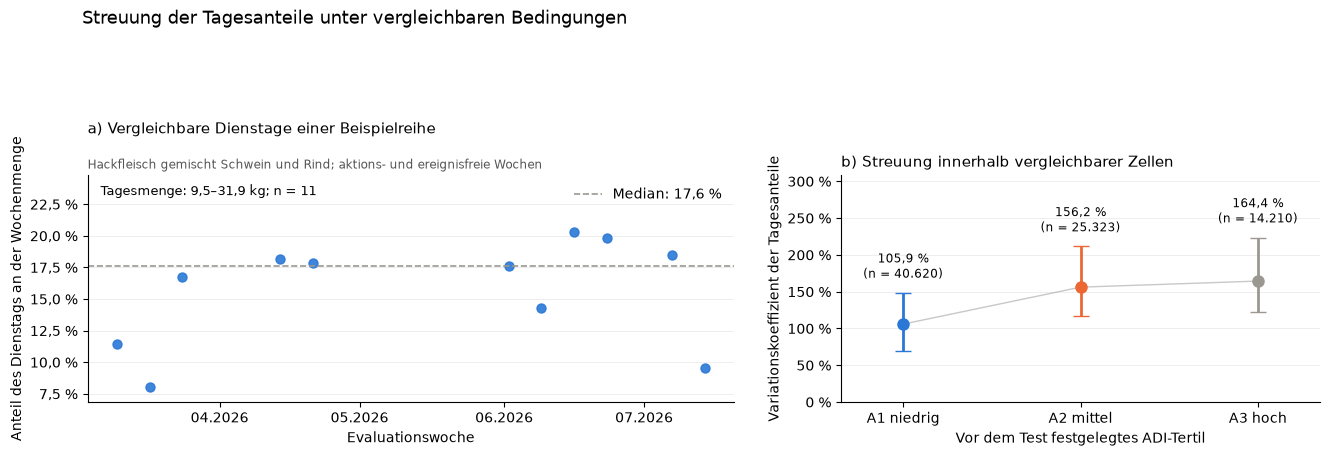

In [13]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from src.models.lightgbm.features.builder import _holiday_calendar

BLUE, ORANGE, GRAY = '#2a78d6', '#eb6834', '#9a9891'
ADI_LABELS = ['A1', 'A2', 'A3']
ADI_NAMES = ['A1 niedrig', 'A2 mittel', 'A3 hoch']
CLASSIFICATION_CUTOFF = pd.Timestamp('2026-02-02')

# Reconstruct the frozen ADI classes from history strictly before the cutoff.
con.execute('''
    CREATE OR REPLACE TEMP TABLE dispersion_rows AS
    SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
           CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
           actual::DOUBLE AS actual,
           EXTRACT(ISODOW FROM CAST(period AS DATE)) AS weekday,
           action_on_forecast_day::INTEGER AS act
    FROM read_csv_auto(?)
    WHERE is_active
''', [str(forecast_path)])

series_keys = con.execute('''
    SELECT DISTINCT ARTIKEL_ID, MARKT_ID FROM dispersion_rows
''').fetchdf()
con.register('dispersion_series_keys', series_keys)
frozen_history = con.execute('''
    WITH daily AS (
        SELECT d.ARTIKEL_ID::BIGINT AS ARTIKEL_ID,
               d.MARKT_ID::BIGINT AS MARKT_ID,
               CAST(d.DATE AS DATE) AS period,
               SUM(CAST(COALESCE(d.ABVERKAUFTE_MENGE_KG, 0) AS DOUBLE))
                   AS demand
        FROM read_parquet(?) AS d
        INNER JOIN dispersion_series_keys AS s
            ON d.ARTIKEL_ID = s.ARTIKEL_ID AND d.MARKT_ID = s.MARKT_ID
        WHERE d.is_active
          AND (d.is_fcm OR d.is_pseudo)
          AND d.WGR_ID IN (890, 900)
          AND CAST(d.DATE AS DATE) < ?
        GROUP BY d.ARTIKEL_ID, d.MARKT_ID, period
    )
    SELECT ARTIKEL_ID, MARKT_ID, COUNT(*) AS n_operational_days,
           COUNT_IF(demand > 0) AS n_pos,
           COUNT(*)::DOUBLE / NULLIF(COUNT_IF(demand > 0), 0) AS ADI
    FROM daily GROUP BY ARTIKEL_ID, MARKT_ID
''', [str(design.data_dir / '*.parquet'), CLASSIFICATION_CUTOFF.date()]).fetchdf()

series_regimes = series_keys.merge(
    frozen_history, on=['ARTIKEL_ID', 'MARKT_ID'], how='left',
    validate='one_to_one',
)
series_regimes[['n_operational_days', 'n_pos']] = series_regimes[[
    'n_operational_days', 'n_pos'
]].fillna(0).astype('int64')
eligible = series_regimes.n_pos.ge(5)
series_regimes['adi_bin'] = pd.Series(
    pd.NA, index=series_regimes.index, dtype='string'
)
series_regimes.loc[eligible, 'adi_bin'] = pd.qcut(
    series_regimes.loc[eligible, 'ADI'], 3, labels=ADI_LABELS
).astype('string').to_numpy()
assert eligible.sum() == 21_140
con.register(
    'frozen_adi_regimes',
    series_regimes.loc[eligible, ['ARTIKEL_ID', 'MARKT_ID', 'adi_bin']],
)

period_min, period_max = con.execute('''
    SELECT MIN(period), MAX(period) FROM dispersion_rows
''').fetchone()
event_calendar = _holiday_calendar(period_min, period_max)[
    ['period', 'holiday_event_window']
]
con.register('dispersion_calendar', event_calendar)
con.execute('''
    CREATE OR REPLACE TEMP TABLE adi_weekly_rows AS
    WITH joined AS (
        SELECT r.*, g.adi_bin, c.holiday_event_window
        FROM dispersion_rows AS r
        INNER JOIN frozen_adi_regimes AS g
            USING (ARTIKEL_ID, MARKT_ID)
        INNER JOIN dispersion_calendar AS c USING (period)
    )
    SELECT *,
           SUM(actual) OVER series_week AS week_total,
           MAX(act) OVER series_week AS week_has_action,
           MAX((holiday_event_window <> 'none')::INTEGER) OVER series_week
               AS week_has_event
    FROM joined
    WINDOW series_week AS (
        PARTITION BY ARTIKEL_ID, MARKT_ID, origin
    )
''')

cell_cv = con.execute('''
    WITH cells AS (
        SELECT adi_bin, ARTIKEL_ID, MARKT_ID, weekday,
               COUNT(*) AS observations,
               AVG(actual / week_total) AS mean_share,
               STDDEV_SAMP(actual / week_total) AS sd_share
        FROM adi_weekly_rows
        WHERE week_total > 0 AND week_has_action = 0 AND week_has_event = 0
        GROUP BY adi_bin, ARTIKEL_ID, MARKT_ID, weekday
        HAVING COUNT(*) >= 5 AND AVG(actual / week_total) > 0
    )
    SELECT *, sd_share / mean_share AS cv FROM cells
''').fetchdf()
cell_cv['adi_bin'] = pd.Categorical(
    cell_cv.adi_bin, categories=ADI_LABELS, ordered=True
)
dispersion_summary = (
    cell_cv.groupby('adi_bin', observed=True).cv
    .agg(cells='size', q25=lambda values: values.quantile(.25),
         median='median', q75=lambda values: values.quantile(.75))
    .reindex(ADI_LABELS).reset_index()
)
display(dispersion_summary.style.format({
    'cells': '{:,.0f}', 'q25': '{:.1%}', 'median': '{:.1%}', 'q75': '{:.1%}',
}))

# Select a high-volume, almost continuously selling A1 example with enough
# comparable Tuesdays; the rule is deterministic rather than hand-picked.
EXAMPLE_ARTICLE, EXAMPLE_STORE = con.execute('''
    SELECT ARTIKEL_ID, MARKT_ID
    FROM adi_weekly_rows
    WHERE adi_bin = 'A1'
    GROUP BY ARTIKEL_ID, MARKT_ID
    HAVING AVG((actual > 0)::INTEGER) >= 0.99
       AND COUNT_IF(weekday = 2 AND week_has_action = 0
                    AND week_has_event = 0) >= 5
    ORDER BY SUM(actual) DESC
    LIMIT 1
''').fetchone()
EXAMPLE_ARTICLE_BEZ, = con.execute('''
    SELECT ARG_MAX(ARTIKEL_BEZ, CAST(DATE AS DATE)) FILTER (
        WHERE ARTIKEL_BEZ IS NOT NULL AND TRIM(ARTIKEL_BEZ) <> ''
    )
    FROM read_parquet(?)
    WHERE ARTIKEL_ID = ? AND MARKT_ID = ?
''', [str(design.data_dir / '*.parquet'),
      EXAMPLE_ARTICLE, EXAMPLE_STORE]).fetchone()
if not EXAMPLE_ARTICLE_BEZ:
    raise ValueError('Missing ARTIKEL_BEZ for the selected example series')
example = con.execute('''
    SELECT period, actual, actual / week_total AS day_share
    FROM adi_weekly_rows
    WHERE ARTIKEL_ID = ? AND MARKT_ID = ? AND weekday = 2
      AND week_total > 0 AND week_has_action = 0 AND week_has_event = 0
    ORDER BY period
''', [EXAMPLE_ARTICLE, EXAMPLE_STORE]).fetchdf()
example['period'] = pd.to_datetime(example.period)

def percent_de(value, decimals=1):
    return f'{100 * value:.{decimals}f} %'.replace('.', ',')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.4, 5.1),
                               gridspec_kw={'width_ratios': [1.35, 1]})

ax1.scatter(example.period, example.day_share, s=42, color=BLUE, alpha=.9)
median_share = example.day_share.median()
ax1.axhline(median_share, color=GRAY, linewidth=1.2, linestyle='--',
            label=f'Median: {percent_de(median_share)}')
ax1.set_title('a) Vergleichbare Dienstage einer Beispielreihe',
              fontsize=11, loc='left', pad=30)
ax1.text(0, 1.015,
         f'{EXAMPLE_ARTICLE_BEZ}; aktions- und ereignisfreie Wochen',
         transform=ax1.transAxes, fontsize=8.5, color='#555555', va='bottom')
ax1.set_xlabel('Evaluationswoche')
ax1.set_ylabel('Anteil des Dienstags an der Wochenmenge')
ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: percent_de(value))
)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m.%Y'))
ax1.set_ylim(example.day_share.min() * .85, example.day_share.max() * 1.22)
ax1.legend(frameon=False, loc='upper right')
ax1.text(.02, .96,
         ('Tagesmenge: '
          f'{example.actual.min():.1f}–{example.actual.max():.1f} kg; '
          f'n = {len(example)}').replace('.', ','),
         transform=ax1.transAxes, va='top', fontsize=9)

positions = np.arange(1, 4)
medians = dispersion_summary['median'].to_numpy()
lower = medians - dispersion_summary['q25'].to_numpy()
upper = dispersion_summary['q75'].to_numpy() - medians
colors = [BLUE, ORANGE, GRAY]
for x, median, lo, hi, color, cells in zip(
    positions, medians, lower, upper, colors, dispersion_summary['cells']
):
    ax2.errorbar(x, median, yerr=[[lo], [hi]], fmt='o', markersize=8,
                 capsize=6, linewidth=2, color=color)
    cell_count = f'{int(cells):,}'.replace(',', '.')
    ax2.annotate(f'{percent_de(median)}\n(n = {cell_count})',
                 xy=(x, median + hi), xytext=(0, 8),
                 textcoords='offset points', ha='center', va='bottom',
                 fontsize=8.5)
ax2.plot(positions, medians, color='#c8c8c8', linewidth=1, zorder=0)
ax2.set_xticks(positions, ADI_NAMES)
ax2.set_title('b) Streuung innerhalb vergleichbarer Zellen', fontsize=11, loc='left')
ax2.set_xlabel('Vor dem Test festgelegtes ADI-Tertil')
ax2.set_ylabel('Variationskoeffizient der Tagesanteile')
ax2.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: percent_de(value, decimals=0))
)
ax2.set_xlim(.65, 3.35)
ax2.set_ylim(0, max(dispersion_summary.q75) * 1.38)

for ax in (ax1, ax2):
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
fig.suptitle('Streuung der Tagesanteile unter vergleichbaren Bedingungen',
             fontsize=13, x=.065, y=.985, ha='left')
fig.tight_layout(rect=[0, .10, 1, .86], w_pad=2.4)
plt.show()

### Addendum 3 conclusions

A1's 48.3% decomposes into three parts with very different tractability:

1. **~11.8 pp: weekly totals** (48.3% → 36.5% with true week totals under the
   model's own shape). Systematic — the weekly signed bias swings ±20% in
   event/post-event weeks — and therefore the legitimate target of the
   event-feature programme.
2. **~2 pp: within-week allocation.** The model's shape already beats the
   future-knowledge static weekday profile (36.5% vs 37.5%); the best
   observable-conditioned profile (weekday × action) reaches 34.4%, and granting
   **perfect same-day footfall** on top reaches 33.6% — an upper bound of ~0.8 pp
   over the weekday × action profile that no real forecast attains, since
   target-day footfall is itself unknown 1–7 days ahead and its predictable part
   (weekday, actions, holidays) is already in the model's features. Log-footfall
   deviations explain only r ≈ 0.18 of day-level demand deviations (~3% of
   variance). **Footfall data is therefore not a lever at this grain**; at most it
   is a cheap auxiliary regressor for week-level store traffic trends.
3. **The remainder: day-level dispersion and residual occurrence error.** Same
   store, same article, same weekday, same promo state, week level removed —
   daily demand still scatters with a ~96% median coefficient of variation across
   51,023 cells. Oracle B's 18.2% is reachable only by copying the realized draw;
   no leakage-free forecast of any kind closes this part.

**What changed in the 2026-08-17 re-cut.** On the old realized-occurrence high
band the equivalent decomposition read ~10 pp weekly totals, ≤1–2 pp allocation,
~24 pp irreducible, against a 37.8% total. The *shape* of the finding is
unchanged — weekly totals are the tractable part, within-week allocation is
already near-optimal, footfall is not a lever — but the levels are higher because
A1 is a broader and genuinely harder class than a band selected on ≥90% realized
occurrence. The old numbers should not be quoted; they described a population
defined by its own outcome.